# Scaling, Encoding & Distance — সম্পূর্ণ নোট
### AI-ML Course | Module 3 | Feature Preprocessing
---
> **কেন এই chapter গুরুত্বপূর্ণ?**  
> ML model-এ raw data সরাসরি দিলে ভালো result আসে না।  
> Scaling → feature-গুলো একই range-এ আনে।  
> Encoding → categorical data-কে numeric-এ রূপান্তর করে।  
> Distance → model-গুলো কীভাবে "কাছে/দূরে" বোঝে তা শেখায়।


---
## 3.2 Standardization — ধারণা

### সমস্যাটা কী?
ধরো একটি dataset-এ দুটো feature আছে:
- **বয়স:** ১৮ – ৬০ (range ছোট)
- **বেতন:** ২০,০০০ – ২,০০,০০০ (range বিশাল)

KNN বা Linear Regression-এর মতো model distance বা magnitude দেখে।  
বেতন feature টা বয়স-কে "চাপা দিয়ে" দেবে — model bias হবে।

**Standardization** এই সমস্যার সমাধান করে।

---

### Standardization (Z-score Normalization)

প্রতিটি value থেকে **mean বাদ দিয়ে** **standard deviation দিয়ে ভাগ** করা হয়:

$$z = \frac{x - \mu}{\sigma}$$

| চিহ্ন | মানে |
|---|---|
| $x$ | original value |
| $\mu$ | column-এর mean |
| $\sigma$ | column-এর standard deviation |
| $z$ | standardized value |

### Output-এর বৈশিষ্ট্য
- **Mean → 0**, **Standard Deviation → 1**
- Range নির্দিষ্ট নয় (theoretically −∞ থেকে +∞)
- Outlier থাকলে সেটা রাখে, কিন্তু প্রভাব কমায়

### 🎯 কখন ব্যবহার করবে?
| ব্যবহার করো | ব্যবহার করো না |
|---|---|
| Data normally distributed হলে | Data-তে hard upper/lower bound দরকার হলে |
| Linear Regression, SVM, PCA, KNN | Tree-based model (Decision Tree, Random Forest) |
| Outlier থাকলেও চলে | Min-Max দরকার হলে |

### 🎯 Interview Trap
> Standardization outlier **remove** করে না, শুধু scale করে।  
> Mean = 0, SD = 1 guarantee করে — কিন্তু range [0,1] **না**।


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Manual Standardization example
salaries = np.array([25000, 40000, 55000, 70000, 200000])  # has outlier

mean = salaries.mean()
std  = salaries.std()

z_scores = (salaries - mean) / std

print(f"Original:       {salaries}")
print(f"Mean:           {mean:.2f}")
print(f"Std Dev:        {std:.2f}")
print(f"Z-scores:       {np.round(z_scores, 3)}")
print(f"After Mean:     {z_scores.mean():.10f}  -> approx 0")
print(f"After Std Dev:  {z_scores.std():.10f}  -> approx 1")

Original:       [ 25000  40000  55000  70000 200000]
Mean:           78000.00
Std Dev:        62817.20
Z-scores:       [-0.844 -0.605 -0.366 -0.127  1.942]
After Mean:     -0.0000000000  -> approx 0
After Std Dev:  1.0000000000  -> approx 1


---
## 3.3 Standardization — Python Implementation

Scikit-learn-এর `StandardScaler` ব্যবহার করা হয়।

### Workflow
```
fit()       → mean ও std শেখে (training data থেকে)
transform() → সেই mean/std দিয়ে scale করে
fit_transform() → দুটো একসাথে (শুধু train-এ)
inverse_transform() → original scale-এ ফিরিয়ে আনে
```

### 🎯 Critical Rule
> **শুধু training data-তে `fit()` করো।**  
> Test data-তে শুধু `transform()` করো।  
> Test data-র mean/std ব্যবহার করলে **data leakage** হয়।


In [2]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Create dataset
data = {
    "age":        [22, 35, 28, 45, 55, 30],
    "salary":     [25000, 60000, 40000, 90000, 120000, 50000],
    "experience": [1, 8, 4, 15, 20, 6]
}
df = pd.DataFrame(data)
print("Original Data:")
print(df)

Original Data:
   age  salary  experience
0   22   25000           1
1   35   60000           8
2   28   40000           4
3   45   90000          15
4   55  120000          20
5   30   50000           6


In [3]:
from sklearn.model_selection import train_test_split

X = df.values
X_train, X_test = train_test_split(X, test_size=0.33, random_state=42)

scaler = StandardScaler()

# fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test data
X_test_scaled = scaler.transform(X_test)

print("Train (scaled):")
print(np.round(X_train_scaled, 3))
print(f"\nMean (train scaled): {X_train_scaled.mean(axis=0).round(10)}")
print(f"Std  (train scaled): {X_train_scaled.std(axis=0).round(10)}")

print("\nTest (scaled using train's mean/std):")
print(np.round(X_test_scaled, 3))

Train (scaled):
[[-0.856 -0.781 -0.804]
 [-1.036 -1.093 -1.11 ]
 [ 1.396  1.406  1.339]
 [ 0.495  0.469  0.574]]

Mean (train scaled): [ 0. -0.  0.]
Std  (train scaled): [1. 1. 1.]

Test (scaled using train's mean/std):
[[-1.576 -1.562 -1.569]
 [-0.405 -0.469 -0.497]]


In [4]:
# inverse_transform — go back to original scale
X_back = scaler.inverse_transform(X_train_scaled)
print("Recovered original values:")
print(np.round(X_back, 1))

# inspect learned mean and std
print(f"\nScaler mean_: {scaler.mean_}")
print(f"Scaler scale_: {scaler.scale_}")

Recovered original values:
[[3.0e+01 5.0e+04 6.0e+00]
 [2.8e+01 4.0e+04 4.0e+00]
 [5.5e+01 1.2e+05 2.0e+01]
 [4.5e+01 9.0e+04 1.5e+01]]

Scaler mean_: [3.950e+01 7.500e+04 1.125e+01]
Scaler scale_: [1.11018017e+01 3.20156212e+04 6.53356717e+00]


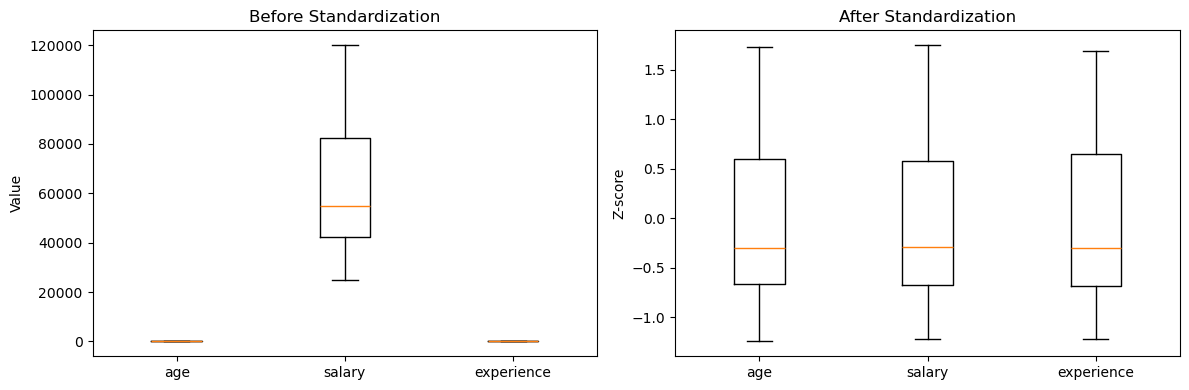

Chart saved.


In [5]:
# Visualization — before vs after
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

X_all = df.values
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X_all)

labels = ["age", "salary", "experience"]

axes[0].boxplot(X_all, tick_labels=labels)
axes[0].set_title("Before Standardization")
axes[0].set_ylabel("Value")

axes[1].boxplot(X_scaled, tick_labels=labels)
axes[1].set_title("After Standardization")
axes[1].set_ylabel("Z-score")

plt.tight_layout()
plt.savefig("standardization.png", dpi=100)
plt.show()
print("Chart saved.")

---
## 3.4 Min-Max Scaling — ধারণা

### কী করে?
প্রতিটি value-কে **[0, 1]** range-এ নিয়ে আসে।

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

### Output-এর বৈশিষ্ট্য
- সর্বনিম্ন value → **0**, সর্বোচ্চ value → **1**
- সব value [0, 1] range-এর মধ্যে
- Data-র shape/distribution অপরিবর্তিত থাকে

### Standardization vs Min-Max

| বিষয় | Standardization | Min-Max |
|---|---|---|
| Formula | $(x-\mu)/\sigma$ | $(x-min)/(max-min)$ |
| Output range | যেকোনো real number | [0, 1] |
| Mean | 0 | নির্দিষ্ট নয় |
| Outlier প্রভাব | কম | **বেশি** (range টানে) |
| কখন ব্যবহার | Normal distribution, SVM, PCA | Neural Network, Image data, bound দরকার হলে |

### 🎯 Interview Trap
> Outlier থাকলে Min-Max **ক্ষতিগ্রস্ত হয়।**  
> একটা extreme outlier পুরো scale টেনে ধরে — বাকি সব data ছোট range-এ চাপা পড়ে।  
> এই ক্ষেত্রে **Robust Scaling** ব্যবহার করো।


In [6]:
import numpy as np

# Manual Min-Max Scaling
scores = np.array([10, 20, 30, 40, 50])

x_min = scores.min()
x_max = scores.max()

scaled = (scores - x_min) / (x_max - x_min)

print(f"Original: {scores}")
print(f"Min: {x_min}, Max: {x_max}")
print(f"Scaled:   {scaled}")

# Effect of outlier
scores_with_outlier = np.array([10, 20, 30, 40, 500])  # 500 is outlier
x_min2 = scores_with_outlier.min()
x_max2 = scores_with_outlier.max()
scaled2 = (scores_with_outlier - x_min2) / (x_max2 - x_min2)
print(f"\nWith outlier scaled: {np.round(scaled2, 3)}")
print("10-40 all squeezed into [0, 0.06] range!")

Original: [10 20 30 40 50]
Min: 10, Max: 50
Scaled:   [0.   0.25 0.5  0.75 1.  ]

With outlier scaled: [0.    0.02  0.041 0.061 1.   ]
10-40 all squeezed into [0, 0.06] range!


---
## 3.5 Min-Max Scaling — Python Implementation

Scikit-learn-এর `MinMaxScaler` ব্যবহার করা হয়।  
Default range [0, 1] — কিন্তু `feature_range` parameter দিয়ে বদলানো যায়।


In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

data = {
    "age":        [22, 35, 28, 45, 55, 30],
    "salary":     [25000, 60000, 40000, 90000, 120000, 50000],
    "experience": [1, 8, 4, 15, 20, 6]
}
df = pd.DataFrame(data)

scaler = MinMaxScaler()                          # default: [0, 1]
scaler_custom = MinMaxScaler(feature_range=(-1, 1))  # custom range

X = df.values
X_scaled    = scaler.fit_transform(X)
X_scaled_c  = scaler_custom.fit_transform(X)

print("Original:")
print(df.to_string(index=False))
print("\nMin-Max Scaled [0,1]:")
print(np.round(X_scaled, 3))
print("\nMin-Max Scaled [-1,1]:")
print(np.round(X_scaled_c, 3))

Original:
 age  salary  experience
  22   25000           1
  35   60000           8
  28   40000           4
  45   90000          15
  55  120000          20
  30   50000           6

Min-Max Scaled [0,1]:
[[0.    0.    0.   ]
 [0.394 0.368 0.368]
 [0.182 0.158 0.158]
 [0.697 0.684 0.737]
 [1.    1.    1.   ]
 [0.242 0.263 0.263]]

Min-Max Scaled [-1,1]:
[[-1.    -1.    -1.   ]
 [-0.212 -0.263 -0.263]
 [-0.636 -0.684 -0.684]
 [ 0.394  0.368  0.474]
 [ 1.     1.     1.   ]
 [-0.515 -0.474 -0.474]]


In [8]:
# Inverse transform
X_back = scaler.inverse_transform(X_scaled)
print("Recovered original values:")
print(np.round(X_back, 1))

# Train/Test split — same rule applies!
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.33, random_state=42)
scaler3 = MinMaxScaler()
X_train_sc = scaler3.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler3.transform(X_test)         # transform only on test

print("\nScaler data_min_:", scaler3.data_min_)
print("Scaler data_max_:", scaler3.data_max_)

Recovered original values:
[[2.2e+01 2.5e+04 1.0e+00]
 [3.5e+01 6.0e+04 8.0e+00]
 [2.8e+01 4.0e+04 4.0e+00]
 [4.5e+01 9.0e+04 1.5e+01]
 [5.5e+01 1.2e+05 2.0e+01]
 [3.0e+01 5.0e+04 6.0e+00]]

Scaler data_min_: [2.8e+01 4.0e+04 4.0e+00]
Scaler data_max_: [5.5e+01 1.2e+05 2.0e+01]


---
## 3.6 Robust Scaling — ধারণা

### কেন দরকার?
Standardization ও Min-Max উভয়ই outlier দ্বারা প্রভাবিত হয়।  
Outlier-heavy data-তে এগুলো ভালো কাজ করে না।

**Robust Scaling** outlier-কে **উপেক্ষা করে** — median ও IQR ব্যবহার করে।

### Formula

$$x_{scaled} = \frac{x - Q_2}{Q_3 - Q_1} = \frac{x - \text{median}}{\text{IQR}}$$

| চিহ্ন | মানে |
|---|---|
| $Q_2$ | Median (50th percentile) |
| $Q_1$ | 25th percentile |
| $Q_3$ | 75th percentile |
| IQR | $Q_3 - Q_1$ (Interquartile Range) |

### কেন Robust?
- **Median** outlier দ্বারা প্রভাবিত হয় না (mean-এর মতো টানে না)
- **IQR** শুধু মাঝের ৫০% data দেখে — extreme value ignore করে

### তিনটি Scaler-এর তুলনা

| বিষয় | Standard | Min-Max | Robust |
|---|---|---|---|
| Center | Mean | Min | Median |
| Scale | Std Dev | Range | IQR |
| Outlier সহনশীল | মাঝারি | **না** | **হ্যাঁ** |
| Output range | যেকোনো | [0,1] | যেকোনো |
| কখন | Normal dist | Bounded, NN | Outlier আছে |

### 🎯 Interview Tip
> "Data-তে outlier থাকলে কোন scaler ব্যবহার করবে?" → **RobustScaler**  
> "Neural network-এ কোনটা?" → **MinMaxScaler** (activation function [0,1] বা [-1,1] চায়)  
> "PCA বা SVM-এ?" → **StandardScaler**


In [9]:
import numpy as np

# Manual Robust Scaling
salaries = np.array([30000, 35000, 40000, 42000, 45000, 200000])  # 200000 is outlier

Q1 = np.percentile(salaries, 25)
Q2 = np.percentile(salaries, 50)   # median
Q3 = np.percentile(salaries, 75)
IQR = Q3 - Q1

robust_scaled = (salaries - Q2) / IQR

print(f"Data:          {salaries}")
print(f"Q1={Q1}, Median={Q2}, Q3={Q3}, IQR={IQR}")
print(f"Robust Scaled: {np.round(robust_scaled, 3)}")
print(f"\nOutlier (200000) scaled to: {robust_scaled[-1]:.3f}")
print("Large outlier did not distort the rest of the scale!")

# Compare with Min-Max
mm = (salaries - salaries.min()) / (salaries.max() - salaries.min())
print(f"\nMin-Max scaled: {np.round(mm, 3)}")
print("30000-45000 all squeezed into [0, 0.075] range!")

Data:          [ 30000  35000  40000  42000  45000 200000]
Q1=36250.0, Median=41000.0, Q3=44250.0, IQR=8000.0
Robust Scaled: [-1.375 -0.75  -0.125  0.125  0.5   19.875]

Outlier (200000) scaled to: 19.875
Large outlier did not distort the rest of the scale!

Min-Max scaled: [0.    0.029 0.059 0.071 0.088 1.   ]
30000-45000 all squeezed into [0, 0.075] range!


---
## 3.7 Robust Scaling — Python Implementation


In [10]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

# Dataset with outliers
data = {
    "age":    [22, 30, 28, 35, 33, 90],      # 90 is outlier
    "salary": [25000, 40000, 35000, 50000, 45000, 500000],  # 500000 is outlier
}
df = pd.DataFrame(data)
X = df.values

X_r = RobustScaler().fit_transform(X)
X_s = StandardScaler().fit_transform(X)
X_m = MinMaxScaler().fit_transform(X)

print("Original:")
print(df.to_string(index=False))

print("\nRobust Scaled:")
# X_r.round(3)
print(np.round(X_r, 3))

print("\nStandard Scaled:")
# X_s.round(3)
print(np.round(X_s, 3))

print("\nMin-Max Scaled:")
X_m.round(3)
# print(np.round(X_m, 3))

Original:
 age  salary
  22   25000
  30   40000
  28   35000
  35   50000
  33   45000
  90  500000

Robust Scaled:
[[-1.583 -1.4  ]
 [-0.25  -0.2  ]
 [-0.583 -0.6  ]
 [ 0.583  0.6  ]
 [ 0.25   0.2  ]
 [ 9.75  36.6  ]]

Standard Scaled:
[[-0.772 -0.528]
 [-0.422 -0.441]
 [-0.51  -0.47 ]
 [-0.204 -0.383]
 [-0.291 -0.412]
 [ 2.2    2.234]]

Min-Max Scaled:


array([[0.   , 0.   ],
       [0.118, 0.032],
       [0.088, 0.021],
       [0.191, 0.053],
       [0.162, 0.042],
       [1.   , 1.   ]])

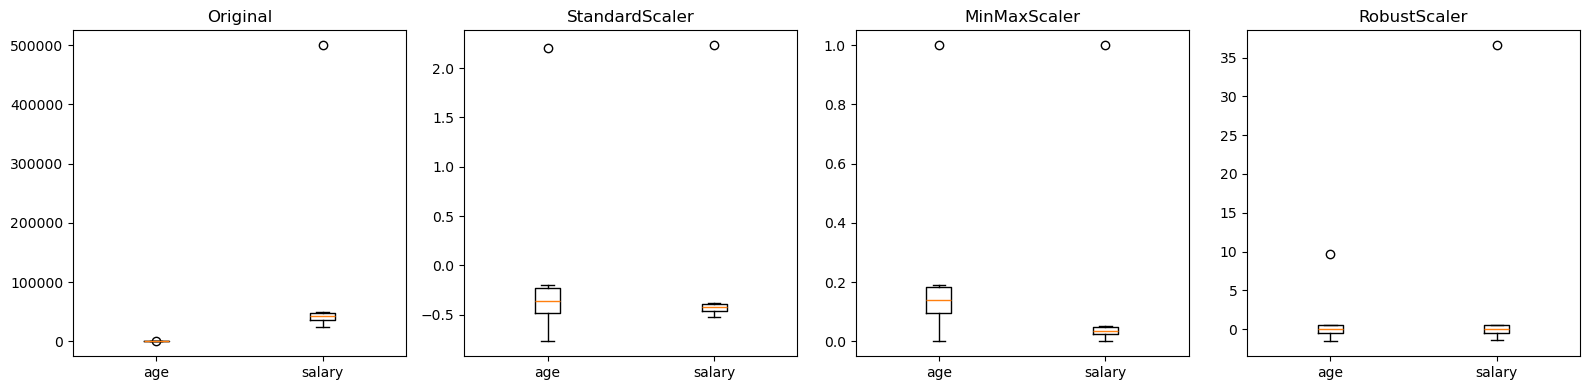

In [11]:
# Visualization — comparing three scalers
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

datasets = [X, X_s, X_m, X_r]
titles   = ["Original", "StandardScaler", "MinMaxScaler", "RobustScaler"]
col_labels = ["age", "salary"]

for ax, data_plot, title in zip(axes, datasets, titles):
    ax.boxplot(data_plot, tick_labels=col_labels)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("scaler_comparison.png", dpi=100)
plt.show()

---
## 3.8 Nominal vs Ordinal Variables এবং One Hot Encoding

### Categorical Variable-এর প্রকারভেদ

ML model শুধু সংখ্যা বোঝে। তাই categorical data-কে numeric-এ রূপান্তর করতে হয়।  
কিন্তু **কীভাবে** encode করবে তা নির্ভর করে variable-এর ধরনের উপর।

---

### Nominal Variable
- Categories-এর মধ্যে **কোনো ক্রম নেই**
- একটা অন্যটার চেয়ে বড় বা ছোট নয়
- উদাহরণ: রঙ (লাল/নীল/সবুজ), দেশ, রক্তের গ্রুপ, লিঙ্গ

### Ordinal Variable
- Categories-এর মধ্যে **ক্রম আছে**
- কিন্তু ক্রমের মধ্যে পার্থক্য সমান নাও হতে পারে
- উদাহরণ: শিক্ষাগত যোগ্যতা (SSC < HSC < BSC), রেটিং (খারাপ < ঠিক < ভালো)

---

### One Hot Encoding (OHE)
**Nominal** variable-এর জন্য ব্যবহার হয়।

প্রতিটি unique category-র জন্য নতুন **binary column** তৈরি হয়।

**উদাহরণ:** রঙ column → লাল, নীল, সবুজ তিনটি column

| রঙ | is_লাল | is_নীল | is_সবুজ |
|---|---|---|---|
| লাল | 1 | 0 | 0 |
| নীল | 0 | 1 | 0 |
| সবুজ | 0 | 0 | 1 |

### 🎯 Dummy Variable Trap
> `n` categories থাকলে শুধু `n-1` column রাখো।  
> শেষ column সবসময় বাকি column থেকে বের করা যায়।  
> `n` column রাখলে **multicollinearity** সমস্যা হয়।  
> Scikit-learn `drop='first'` দিয়ে প্রথম column বাদ দেয়।

### 🎯 কখন OHE ব্যবহার করবে না?
- Category সংখ্যা অনেক বেশি (high cardinality) → Column explosion
- Tree-based model (label encoding ভালো)


---
## 3.9 One Hot Encoding — Python Implementation

দুটো উপায়:
1. **Pandas** `get_dummies()` — দ্রুত, সহজ
2. **Scikit-learn** `OneHotEncoder` — ML pipeline-এ ব্যবহার


In [12]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "name":  ["Alice", "Bob", "Carol", "David", "Eva"],
    "color": ["red", "blue", "green", "red", "blue"],
    "city":  ["Dhaka", "Chittagong", "Dhaka", "Rajshahi", "Chittagong"],
    "age":   [25, 30, 28, 22, 35]
})

print("Original DataFrame:")
print(df)

Original DataFrame:
    name  color        city  age
0  Alice    red       Dhaka   25
1    Bob   blue  Chittagong   30
2  Carol  green       Dhaka   28
3  David    red    Rajshahi   22
4    Eva   blue  Chittagong   35


In [13]:
# Pandas get_dummies — simple method
df_encoded = pd.get_dummies(df, columns=["color", "city"])
print("After One Hot Encoding:")
print(df_encoded)
print("\nColumns:", list(df_encoded.columns))

After One Hot Encoding:
    name  age  color_blue  color_green  color_red  city_Chittagong  \
0  Alice   25       False        False       True            False   
1    Bob   30        True        False      False             True   
2  Carol   28       False         True      False            False   
3  David   22       False        False       True            False   
4    Eva   35        True        False      False             True   

   city_Dhaka  city_Rajshahi  
0        True          False  
1       False          False  
2        True          False  
3       False           True  
4       False          False  

Columns: ['name', 'age', 'color_blue', 'color_green', 'color_red', 'city_Chittagong', 'city_Dhaka', 'city_Rajshahi']


In [14]:
# Avoid Dummy Variable Trap with drop_first=True
df_encoded_safe = pd.get_dummies(df, columns=["color", "city"], drop_first=True)
print("One Hot Encoding (drop_first=True):")
print(df_encoded_safe)
print("\nDropped columns are implicit — derivable from remaining columns")

One Hot Encoding (drop_first=True):
    name  age  color_green  color_red  city_Dhaka  city_Rajshahi
0  Alice   25        False       True        True          False
1    Bob   30        False      False       False          False
2  Carol   28         True      False        True          False
3  David   22        False       True       False           True
4    Eva   35        False      False       False          False

Dropped columns are implicit — derivable from remaining columns


In [15]:
# Scikit-learn OneHotEncoder — for ML pipelines
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(sparse_output=False, drop="first")  # drop first to avoid trap

categories = df[["color", "city"]]
encoded = encoder.fit_transform(categories)

print("Encoded array:")
print(encoded)
print("\nFeature names:", encoder.get_feature_names_out(["color", "city"]))

# View as DataFrame
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["color", "city"])
)
print("\nAs DataFrame:")
print(encoded_df)

Encoded array:
[[0. 1. 1. 0.]
 [0. 0. 0. 0.]
 [1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [0. 0. 0. 0.]]

Feature names: ['color_green' 'color_red' 'city_Dhaka' 'city_Rajshahi']

As DataFrame:
   color_green  color_red  city_Dhaka  city_Rajshahi
0          0.0        1.0         1.0            0.0
1          0.0        0.0         0.0            0.0
2          1.0        0.0         1.0            0.0
3          0.0        1.0         0.0            1.0
4          0.0        0.0         0.0            0.0


---
## 3.10 Ordinal Encoding — ধারণা ও Python Implementation

### কী করে?
**Ordinal** variable-এর প্রতিটি category-কে **ক্রম অনুযায়ী** integer দিয়ে replace করা হয়।

**উদাহরণ:**
| শিক্ষা | Encoded |
|---|---|
| SSC | 0 |
| HSC | 1 |
| BSc | 2 |
| MSc | 3 |

### 🎯 OHE vs Ordinal Encoding

| বিষয় | One Hot Encoding | Ordinal Encoding |
|---|---|---|
| Variable type | Nominal | Ordinal |
| ক্রম | নেই | আছে |
| নতুন column | হ্যাঁ (n বা n-1 টি) | না (১টি column) |
| Model type | Linear model | Tree-based model ও Ordinal data |
| সমস্যা | High cardinality | ভুল ক্রম দিলে model ভুল শেখে |

### 🎯 Interview Trap
> Ordinal encoding-এ ক্রম **তুমি নিজে** ঠিক করো।  
> ভুল ক্রম দিলে model ভুল relationship শিখবে।  
> LabelEncoder ও OrdinalEncoder আলাদা — LabelEncoder target (y) এর জন্য, OrdinalEncoder feature (X) এর জন্য।


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

df = pd.DataFrame({
    "name":       ["Alice", "Bob", "Carol", "David", "Eva"],
    "education":  ["BSc", "MSc", "SSC", "HSC", "MSc"],
    "rating":     ["good", "excellent", "poor", "average", "good"],
    "salary":     [50000, 80000, 20000, 35000, 75000]
})

print("Original:")
print(df)

Original:
    name education     rating  salary
0  Alice       BSc       good   50000
1    Bob       MSc  excellent   80000
2  Carol       SSC       poor   20000
3  David       HSC    average   35000
4    Eva       MSc       good   75000


In [17]:
# OrdinalEncoder — define order manually
edu_order    = [["SSC", "HSC", "BSc", "MSc"]]
rating_order = [["poor", "average", "good", "excellent"]]

enc_edu    = OrdinalEncoder(categories=edu_order)
enc_rating = OrdinalEncoder(categories=rating_order)

df["education_encoded"] = enc_edu.fit_transform(df[["education"]]).astype(int)
df["rating_encoded"]    = enc_rating.fit_transform(df[["rating"]]).astype(int)

print("After Ordinal Encoding:")
print(df)

After Ordinal Encoding:
    name education     rating  salary  education_encoded  rating_encoded
0  Alice       BSc       good   50000                  2               2
1    Bob       MSc  excellent   80000                  3               3
2  Carol       SSC       poor   20000                  0               0
3  David       HSC    average   35000                  1               1
4    Eva       MSc       good   75000                  3               2


In [18]:
# LabelEncoder vs OrdinalEncoder difference
from sklearn.preprocessing import LabelEncoder

# LabelEncoder — for target variable (y)
# assigns integers alphabetically — no control over order
le = LabelEncoder()
labels = ["poor", "good", "average", "excellent"]
le_encoded = le.fit_transform(labels)
print("LabelEncoder (alphabetical):", le_encoded)
print("Classes:", le.classes_)

print("\nOrdinalEncoder lets you define custom order — use it for features (X)")

LabelEncoder (alphabetical): [3 2 0 1]
Classes: ['average' 'excellent' 'good' 'poor']

OrdinalEncoder lets you define custom order — use it for features (X)


In [19]:
# Ordinal Encoding with panda map — simple approach
df2 = pd.DataFrame({
    "rating": ["good", "excellent", "poor", "average", "good"]
})

mapping = {"poor": 0, "average": 1, "good": 2, "excellent": 3}
df2["rating_encoded"] = df2["rating"].map(mapping)

print("Ordinal Encoding with pandas map:")
print(df2)

Ordinal Encoding with pandas map:
      rating  rating_encoded
0       good               2
1  excellent               3
2       poor               0
3    average               1
4       good               2


---
## 3.11 Vectors, Dot Product এবং Norms

### Vector কী?
**Vector** হলো সংখ্যার একটি ordered list যা direction ও magnitude প্রকাশ করে।

ML-এ প্রতিটি **data point = একটি vector**।

$$\vec{v} = [v_1, v_2, \ldots, v_n]$$

উদাহরণ: একজন মানুষ → `[বয়স=25, বেতন=50000, অভিজ্ঞতা=3]` → 3D vector

---

### Dot Product (অভ্যন্তরীণ গুণফল)

দুটো vector-এর element-wise গুণ করে সব যোগ:

$$\vec{a} \cdot \vec{b} = \sum_{i=1}^{n} a_i \cdot b_i = a_1b_1 + a_2b_2 + \ldots + a_nb_n$$

**Geometric অর্থ:**
$$\vec{a} \cdot \vec{b} = |\vec{a}| \cdot |\vec{b}| \cdot \cos\theta$$

| Dot Product | মানে |
|---|---|
| > 0 | same দিকে (θ < 90°) |
| = 0 | perpendicular / orthogonal (θ = 90°) |
| < 0 | বিপরীত দিকে (θ > 90°) |

**ML-এ ব্যবহার:** Linear regression, Neural network, Cosine similarity

---

### Norm (Vector-এর দৈর্ঘ্য/Magnitude)

#### L1 Norm (Manhattan Norm)
$$\|\vec{v}\|_1 = \sum_{i=1}^{n} |v_i|$$

#### L2 Norm (Euclidean Norm) — সবচেয়ে বেশি ব্যবহৃত
$$\|\vec{v}\|_2 = \sqrt{\sum_{i=1}^{n} v_i^2}$$

### 🎯 ML-এ Norm-এর ব্যবহার
| Norm | ML Application |
|---|---|
| L1 | Lasso Regression (sparse solution) |
| L2 | Ridge Regression, Distance calculation |
| L2 normalization | Cosine similarity, NLP embedding |


In [20]:
import numpy as np

# Create vectors
a = np.array([2, 3, 4])
b = np.array([1, 0, 2])

print(f"a = {a}")
print(f"b = {b}")

# Dot Product — three methods
dot1 = np.dot(a, b)
dot2 = a @ b            # @ operator
dot3 = sum(ai * bi for ai, bi in zip(a, b))  # manual

print(f"\nDot Product (np.dot): {dot1}")
print(f"Dot Product (@ op):   {dot2}")
print(f"Dot Product (manual): {dot3}")

# Geometric interpretation
cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
theta_deg = np.degrees(np.arccos(cos_theta))
print(f"\nCosine of angle: {cos_theta:.4f}")
print(f"Angle between vectors: {theta_deg:.2f} degrees")

a = [2 3 4]
b = [1 0 2]

Dot Product (np.dot): 10
Dot Product (@ op):   10
Dot Product (manual): 10

Cosine of angle: 0.8305
Angle between vectors: 33.85 degrees


In [21]:
# Norms
v = np.array([3, 4])

l1_norm   = np.linalg.norm(v, ord=1)   # L1
l2_norm   = np.linalg.norm(v, ord=2)   # L2 (default)
# l2_norm   = np.linalg.norm(v)   # L2 (default)
l2_manual = np.sqrt(np.sum(v**2))      # manual

print(f"Vector: {v}")
print(f"L1 Norm: |3| + |4| = {l1_norm}")
print(f"L2 Norm: sqrt(9+16) = {l2_norm} (manual: {l2_manual})")

# L2 Normalization — create unit vector
v_normalized = v / l2_norm
print(f"\nNormalized vector: {v_normalized}")
print(f"Normalized L2 norm: {np.linalg.norm(v_normalized):.6f}  -> 1.0")

Vector: [3 4]
L1 Norm: |3| + |4| = 7.0
L2 Norm: sqrt(9+16) = 5.0 (manual: 5.0)

Normalized vector: [0.6 0.8]
Normalized L2 norm: 1.000000  -> 1.0


আগের উদাহরণটিতে আমরা 3D (তিনটি মাত্রা) ভেক্টর দেখেছিলাম, আর এই কোডটিতে আমরা **2D (দুইটি মাত্রা)** ভেক্টর দিয়ে কাজ করছি। এটি বোঝা আরও সহজ কারণ একে আমরা গ্রাফ পেপারে কল্পনা করতে পারি।

## ১. ভেক্টর পরিচিতি
```python
v = np.array([3, 4])
```
এখানে `v` একটি ভেক্টর যার $x$ অক্ষ বরাবর মান ৩ এবং $y$ অক্ষ বরাবর মান ৪। গ্রাফে আঁকলে এটি মূলবিন্দু $(0,0)$ থেকে শুরু হয়ে $(3,4)$ বিন্দুতে গিয়ে শেষ হওয়া একটি তীর।

## ২. L1 Norm (Manhattan Norm)
```python
l1_norm = np.linalg.norm(v, ord=1) # Output: 7.0
```
**সহজ নিয়ম:** ভেক্টরের উপাদানগুলোর শুধু ধনাত্মক মানগুলোর যোগফল।
$$\|v\|_1 = |3| + |4| = 7$$
কল্পনা করো তুমি একটি শহরে আছো যেখানে রাস্তাগুলো সোজা (Grid)। তোমাকে (০,০) থেকে (৩,৪) এ যেতে হলে ৩ ব্লক ডানে এবং ৪ ব্লক উপরে যেতে হবে। মোট ৭ ব্লক পথ—এটাই **L1 Norm**।

## ৩. L2 Norm (Euclidean Norm)
```python
l2_norm = np.linalg.norm(v, ord=2) # Output: 5.0
l2_manual = np.sqrt(np.sum(v**2))  # (3^2 + 4^2) এর রুট
```
**সহজ নিয়ম:** এটি হলো সরাসরি দূরত্ব বা শর্টকাট। অতিভুজ বের করার সূত্র।
$$\|v\|_2 = \sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5$$
তুমি যদি (০,০) থেকে (৩,৪) পর্যন্ত একটি ফিতা দিয়ে মেপে দেখো, তবে তার দৈর্ঘ্য পাবে ঠিক ৫। এটাই ভেক্টরের আসল দৈর্ঘ্য বা **Magnitude**।

## ৪. L2 Normalization (ইউনিট ভেক্টর তৈরি)
```python
v_normalized = v / l2_norm
```
আমরা দেখেছি ভেক্টর `v` এর দৈর্ঘ্য ৫। আমরা চাই এর দিক ঠিক রেখে দৈর্ঘ্য কমিয়ে ১ বানিয়ে ফেলতে। তাই আমরা প্রতিটি মানকে তার মোট দৈর্ঘ্য (৫) দিয়ে ভাগ করি:
* নতুন $x = \frac{3}{5} = 0.6$
* নতুন $y = \frac{4}{5} = 0.8$

তাহলে `v_normalized` হলো `[0.6, 0.8]`।

## ৫. ফলাফল যাচাই
```python
print(f"Normalized L2 norm: {np.linalg.norm(v_normalized):.6f} -> 1.0")
```
এখন যদি আমরা নতুন ভেক্টর `[0.6, 0.8]` এর দৈর্ঘ্য মাপি:
$$\sqrt{0.6^2 + 0.8^2} = \sqrt{0.36 + 0.64} = \sqrt{1.0} = 1.0$$
দেখলে তো? ভেক্টরটি এখন একটি **Unit Vector** হয়ে গেছে কারণ এর দৈর্ঘ্য এখন ঠিক ১।

### সহজ উদাহরণ দিয়ে মনে রাখো:
* তোমার কাছে একটি **৫ মিটার** লম্বা দড়ি আছে যা উত্তর-পূর্ব দিকে মুখ করা।
* দড়িটিকে ৫ দিয়ে ভাগ করলে তুমি **১ মিটার** লম্বা দড়ি পাবে।
* দড়িটির **দিক কিন্তু এখনো সেই উত্তর-পূর্বেই আছে**, শুধু দৈর্ঘ্যটা ১ মিটার হয়ে গেছে।

এটাই হলো **Normalization**। মেশিন লার্নিং বা এআইতে যখন আমাদের কাছে অনেক বড় বড় ডাটা থাকে, সেগুলোকে একটি নির্দিষ্ট মাপে (০ থেকে ১ এর মধ্যে) নিয়ে আসার জন্য আমরা এই পদ্ধতি ব্যবহার করি।

In [22]:
# Cosine Similarity — widely used in NLP
# measures how similar two vectors/documents are in direction

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Three document vectors (simplified word counts)
doc1 = np.array([1, 1, 0, 0])   # "python machine"
doc2 = np.array([1, 1, 1, 0])   # "python machine learning"
doc3 = np.array([0, 0, 0, 1])   # "cooking recipe"

print(f"doc1 vs doc2 similarity: {cosine_similarity(doc1, doc2):.4f}  -> similar")
print(f"doc1 vs doc3 similarity: {cosine_similarity(doc1, doc3):.4f}  -> not similar")

doc1 vs doc2 similarity: 0.8165  -> similar
doc1 vs doc3 similarity: 0.0000  -> not similar


**Cosine Similarity** বিষয়টি খুবই চমৎকার কারণ এটি ভেক্টরের দৈর্ঘ্য কত বড় সেটা না দেখে শুধু দেখে তারা **কোন দিকে** মুখ করে আছে। NLP (Natural Language Processing) বা টেক্সট এনালাইসিসে এটি সবচেয়ে বেশি ব্যবহৃত হয়।

## ১. মূল কনসেপ্ট: Cosine Similarity কী?
সহজ কথায়, Cosine Similarity আমাদের বলে দেয় দুটি ভেক্টর বা ডকুমেন্ট একে অপরের কতটা **কাছাকাছি (Similar)**।
* যদি দুটি ভেক্টর একই দিকে মুখ করে থাকে, তবে তাদের সিমিলারিটি হয় **1** (তারা একদম এক)।
* যদি তারা একে অপরের সাথে ৯০ ডিগ্রি কোণে থাকে, তবে সিমিলারিটি হয় **0** (তাদের মধ্যে কোনো মিল নেই)।

## ২. ফাংশনটি কীভাবে কাজ করছে?
কোডের এই অংশটি দেখো:
```python
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
```
এখানে একটি গাণিতিক সূত্র ব্যবহার করা হয়েছে:
$$\text{Cosine Similarity} = \frac{A \cdot B}{\|A\| \|B\|}$$

* **`np.dot(a, b)`**: এটি হলো ডট প্রোডাক্ট। এটি দেখে দুটি ভেক্টরের মধ্যে কমন কী কী আছে।
* **`np.linalg.norm(a) * np.linalg.norm(b)`**: এটি দুই বন্ধুর গায়ের জোর বা দৈর্ঘ্যের গুণফল।

এই ভাগ করার প্রক্রিয়াটির মাধ্যমে আমরা ভেক্টরের **দৈর্ঘ্যকে (Magnitude)** বাদ দিয়ে দিই। ফলে কোনো ডকুমেন্ট অনেক বড় হোক বা ছোট, শুধু তাতে থাকা শব্দের মিলটুকুই হিসেবে আসে।

## ৩. উদাহরণের ডকুমেন্টগুলো কী বোঝাচ্ছে?
এখানে শব্দগুলোকে সংখ্যায় রূপান্তর করা হয়েছে (যাকে বলে Vectorization)। ধরো আমাদের শব্দগুলো হলো: `[python, machine, learning, cooking]`

* **doc1: `[1, 1, 0, 0]`** (এখানে 'python' এবং 'machine' শব্দ দুটি আছে একবার করে)।
* **doc2: `[1, 1, 1, 0]`** (এখানে 'python', 'machine' এবং 'learning' শব্দ তিনটি আছে)।
* **doc3: `[0, 0, 0, 1]`** (এখানে শুধু 'cooking' শব্দটি আছে)।

## ৪. আউটপুট বিশ্লেষণ

### কেস ১: doc1 বনাম doc2
```python
doc1 vs doc2 similarity: 0.8165 -> similar
```
এখানে দেখা যাচ্ছে doc1 এবং doc2 এর মধ্যে `python` এবং `machine` এই দুটি শব্দ কমন। তাদের দিকের মধ্যে অনেক মিল আছে, তাই রেজাল্ট **1 এর কাছাকাছি (0.81)**। তারা ডাটা সায়েন্স বা টেক রিলেটেড ডকুমেন্ট।

### কেস ২: doc1 বনাম doc3
```python
doc1 vs doc3 similarity: 0.0000 -> not similar
```
এখানে doc1 এ আছে টেক শব্দ, আর doc3 তে আছে রান্নার শব্দ। তাদের মধ্যে **কোনো শব্দই কমন নেই**। জ্যামিতিকভাবে তারা একে অপরের সাথে ৯০ ডিগ্রি কোণে আছে। তাই তাদের সিমিলারিটি **0**।

## কেন এটি দরকার হয়?
ধরো তুমি গুগলে সার্চ করলে "How to learn Python"।
* একটি বড় আর্টিকেলে এই শব্দগুলো ১০বার আছে।
* একটি ছোট ফেসবুক পোস্টে এই শব্দগুলো ১বার আছে।

যদি আমরা শুধু 'সংখ্যা' গুনতাম, তবে বড় আর্টিকেলটিই সবসময় এগিয়ে থাকতো। কিন্তু **Cosine Similarity** ব্যবহার করলে গুগল বুঝতে পারে দুই জায়গাতেই একই বিষয়ে কথা বলা হচ্ছে, কারণ তাদের **দিকের (Topic)** মিল আছে।

**সহজ সারসংক্ষেপ:**
১. ডট প্রোডাক্ট দিয়ে মিল খুঁজে বের করা হয়।
২. দৈর্ঘ্য দিয়ে ভাগ করে ভেক্টরগুলোকে ১ সাইজের বানিয়ে ফেলা হয় (Normalization)।
৩. ফলাফল ১ এর যত কাছে, মিল তত বেশি। ০ মানে কোনো মিল নেই।

---

## 3.12 Euclidean Distance এবং Manhattan Distance

### Distance কেন দরকার?
ML model-গুলো (KNN, K-Means, SVM) data point-গুলোর মধ্যে **দূরত্ব** পরিমাপ করে সিদ্ধান্ত নেয়।

### Euclidean Distance (L2 Distance)
সরল রেখায় দুই point-এর মধ্যে দূরত্ব — **"সরাসরি" দূরত্ব**।

$$d_E = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2}$$

2D-তে: $d_E = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$

### Manhattan Distance (L1 Distance / City Block Distance)
শুধু horizontal ও vertical পথে চলে — **"রাস্তা দিয়ে"** দূরত্ব।

$$d_M = \sum_{i=1}^{n} |a_i - b_i|$$

নামকরণের কারণ: Manhattan শহরের grid-এর মতো movement।

### তুলনা

| বিষয় | Euclidean | Manhattan |
|---|---|---|
| Formula | $\sqrt{\sum(a_i-b_i)^2}$ | $\sum|a_i-b_i|$ |
| Path | সরল রেখা | Grid/axis-এ |
| Outlier সংবেদনশীল | **বেশি** (বর্গ করে) | কম |
| কখন ব্যবহার | Continuous, low-dim data | High-dim, outlier থাকলে |
| ML use | KNN, K-Means | Robust KNN, Sparse data |

### 🎯 Interview Questions
> "KNN-এ কোন distance ব্যবহার করবে?" → Data ও dimension অনুযায়ী।  
> "Euclidean distance-এ scaling কেন জরুরি?" → Feature-গুলোর scale ভিন্ন হলে বড় scale feature দূরত্ব dominate করে। **Scaling আগে করতে হবে।**  
> "High dimension-এ কোনটা ভালো?" → Manhattan (Euclidean curse of dimensionality-র শিকার হয়)।


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Two points
A = np.array([1, 2])
B = np.array([5, 6])

# Euclidean Distance
euclidean = np.sqrt(np.sum((A - B)**2))     # Manual calculation
euclidean_np = np.linalg.norm(A - B)        # Calculation using built in function
print(f"Euclidean Distance: {euclidean:.4f}  ->  {euclidean_np:.4f}")

# Manhattan Distance
manhattan = np.sum(np.abs(A - B))           # Manual calculation

print(f"Point A: {A}, Point B: {B}")
print(f"\nEuclidean Distance: sqrt((5-1)^2 + (6-2)^2) = sqrt({(5-1)**2}+{(6-2)**2}) = {euclidean:.4f}")
print(f"Manhattan Distance: |5-1| + |6-2| = {abs(5-1)}+{abs(6-2)} = {manhattan}")

Euclidean Distance: 5.6569  ->  5.6569
Point A: [1 2], Point B: [5 6]

Euclidean Distance: sqrt((5-1)^2 + (6-2)^2) = sqrt(16+16) = 5.6569
Manhattan Distance: |5-1| + |6-2| = 4+4 = 8


এই কোডটি আসলে গত দুই ধাপে আমরা যা শিখেছি (Euclidean এবং Manhattan distance), সেটিকে খুব সহজ দুটি বিন্দুর মাধ্যমে হাতে-কলমে প্রমাণ করে দেখাচ্ছে। এখানে ম্যাট্রিক্সের বদলে সরাসরি দুটি বিন্দু $A$ এবং $B$ নেওয়া হয়েছে।

## ১. বিন্দু দুটির পরিচয়
* **বিন্দু A:** $[1, 2]$ (অর্থাৎ x-অক্ষে ১ ঘর, y-অক্ষে ২ ঘর)
* **বিন্দু B:** $[5, 6]$ (অর্থাৎ x-অক্ষে ৫ ঘর, y-অক্ষে ৬ ঘর)

## ২. Euclidean Distance (সরাসরি দূরত্ব)
এটি হলো সেই অতিভুজ বা শর্টকাট রাস্তা। কোডে এটি দুইভাবে করা হয়েছে:
1.  **ম্যানুয়ালি:** `np.sqrt(np.sum((A - B)**2))`
2.  **ফাংশন দিয়ে:** `np.linalg.norm(A - B)`

**হিসেবটা দেখো:**
* $x$ এর পার্থক্য: $5 - 1 = 4$
* $y$ এর পার্থক্য: $6 - 2 = 4$
* বর্গের যোগফল: $4^2 + 4^2 = 16 + 16 = 32$
* রুট (Root): $\sqrt{32} \approx 5.6569$

## ৩. Manhattan Distance (রাস্তা দিয়ে ঘোরার দূরত্ব)
এটি কোনো শর্টকাট নেয় না। এটি দেখে আপনাকে মোট কয় ঘর ডানে এবং কয় ঘর উপরে যেতে হচ্ছে।
* **কোড:** `np.sum(np.abs(A - B))`

**হিসেবটা দেখো:**
* $x$ অক্ষ বরাবর কয় ঘর যেতে হবে? $|5 - 1| = 4$ ঘর।
* $y$ অক্ষ বরাবর কয় ঘর যেতে হবে? $|6 - 2| = 4$ ঘর।
* মোট দূরত্ব: $4 + 4 = 8$।

## ৪. কোডটির বিশেষ কিছু ফাংশন:
* **`np.abs()`**: এটি সব নেগেটিভ (মাইনাস) সংখ্যাকে পজিটিভ করে দেয়। কারণ দূরত্ব কখনও মাইনাস হতে পারে না।
* **`f"{euclidean:.4f}"`**: এটি প্রিন্ট করার সময় দশমিকের পর মাত্র ৪ ঘর দেখানোর জন্য ব্যবহার করা হয়েছে।
* **`A - B`**: এটি সরাসরি দুটি ভেক্টরের বিয়োগফল বের করে দেয়: $[1-5, 2-6] = [-4, -4]$।

## ৫. মূল পার্থক্যটা কোথায়?
একই দুটি বিন্দুর ($A$ এবং $B$) ক্ষেত্রে:
* তুমি যদি পাখি হয়ে উড়ে যাও (Euclidean), তোমাকে **৫.৬৫** কিলোমিটার যেতে হবে।
* তুমি যদি শহরের রাস্তা দিয়ে রিকশা করে যাও (Manhattan), তোমাকে **৮** কিলোমিটার যেতে হবে।

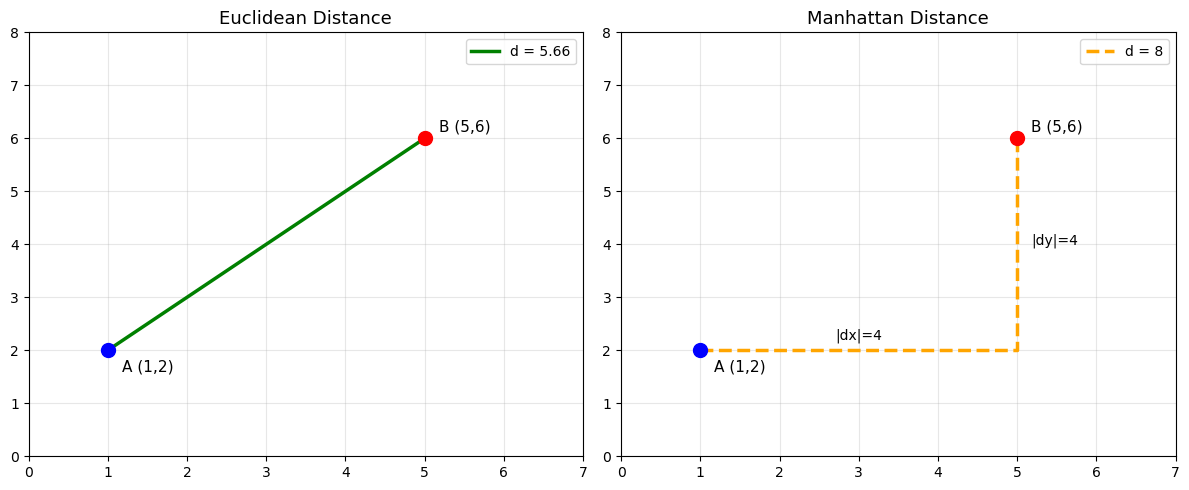

In [24]:
# Visualization — Euclidean vs Manhattan
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

A = np.array([1, 2])
B = np.array([5, 6])

for ax, title in zip(axes, ["Euclidean Distance", "Manhattan Distance"]):
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 8)
    ax.grid(True, alpha=0.3)
    ax.scatter(*A, color="blue", s=100, zorder=5)
    ax.scatter(*B, color="red", s=100, zorder=5)
    ax.annotate("A (1,2)", A, textcoords="offset points", xytext=(10, -15), fontsize=11)
    ax.annotate("B (5,6)", B, textcoords="offset points", xytext=(10, 5), fontsize=11)
    ax.set_title(title, fontsize=13)

# Euclidean — straight line
axes[0].plot([A[0], B[0]], [A[1], B[1]], "g-", linewidth=2.5, label=f"d = {euclidean:.2f}")
axes[0].legend()

# Manhattan — grid path
axes[1].plot([A[0], B[0], B[0]], [A[1], A[1], B[1]], "orange", linewidth=2.5,
             linestyle="--", label=f"d = {manhattan}")
axes[1].annotate(f"|dx|={abs(B[0] - A[0])}", xy=((A[0] + B[0]) / 2, A[1]),
                 xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)
axes[1].annotate(f"|dy|={abs(B[1] - A[1])}", xy=(B[0], (A[1] + B[1]) / 2),
                 xytext=(10, 0), textcoords="offset points", fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.savefig("distances.png", dpi=100)
plt.show()

এতক্ষণ আমরা যা গাণিতিকভাবে শিখলাম, এই কোডটি সেই পুরো বিষয়টিকে একটি **গ্রাফ বা ছবিতে (Visualization)** রূপান্তর করছে। পাইথনের `matplotlib` লাইব্রেরি ব্যবহার করে এখানে দুটি আলাদা ছবি আঁকা হচ্ছে যাতে পার্থক্যটা চোখে দেখে বোঝা যায়।

## ১. গ্রাফের ক্যানভাস তৈরি করা
```python
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
```
এখানে `subplots(1, 2)` মানে হলো আমরা একটি বড় ফ্রেমে পাশাপাশি **দুটি ছবি** আঁকতে চাচ্ছি। `figsize` দিয়ে ছবির আকার সেট করা হয়েছে।

## ২. বিন্দুগুলো বসানো (Scatter Plot)
```python
ax.scatter(*A, color="blue", s=100, zorder=5)
ax.scatter(*B, color="red",  s=100, zorder=5)
```
এই লাইনগুলো গ্রাফের ওপর বিন্দু বসায়।
* **Blue Point:** বিন্দু A (1, 2)
* **Red Point:** বিন্দু B (5, 6)
* `annotate` ফাংশনটি দিয়ে বিন্দুর পাশে নাম লিখে দেওয়া হয়েছে যেন আমরা চিনতে পারি।

## ৩. বাম পাশের ছবি: Euclidean Distance
```python
axes[0].plot([A[0], B[0]], [A[1], B[1]], "g-")
```
এখানে `g-` মানে হলো **Green Solid Line**।
* এটি বিন্দু A থেকে B পর্যন্ত একটি **একদম সোজা সবুজ দাগ** টেনে দেয়।
* এটাই আমাদের সেই শর্টকাট বা অতিভুজ, যার মান ছিল $\approx 5.66$।

## ৪. ডান পাশের ছবি: Manhattan Distance
```python
axes[1].plot([A[0], B[0], B[0]], [A[1], A[1], B[1]], "orange", linestyle="--")
```
এখানে `orange` এবং `--` মানে হলো **কমলা রঙের ড্যাশ লাইন**।
* এই লাইনটি প্রথমে সোজা ডানে যায় (x-অক্ষ বরাবর), তারপর সোজা উপরে যায় (y-অক্ষ বরাবর)।
* এটি সরাসরি না গিয়ে একটি **কোণ (L-shape)** তৈরি করে।
* কোডের `annotate` অংশটি ছবির মাঝখানে লিখে দিচ্ছে:
    * **|dx| = 4:** অর্থাৎ ডানে ৪ ঘর গেল।
    * **|dy| = 4:** অর্থাৎ উপরে ৪ ঘর গেল।
    * মোট দূরত্ব: $4 + 4 = 8$।

## ৫. গ্রাফটি সাজানো
* **`ax.grid(True)`**: গ্রাফের পেছনে ছোট ছোট ঘর বা জাল তৈরি করে, যাতে ঘরগুলো গুনে দূরত্ব বোঝা সহজ হয়।
* **`ax.legend()`**: ছবির কোণায় একটি ছোট বক্স দেখায় যেখানে লেখা থাকে কোনটা কীসের লাইন এবং ডিস্টেন্স কত।

### এই ভিজুয়ালাইজেশন থেকে আমরা কী শিখলাম?

১. **Euclidean (বাম পাশের ছবি):** এটি হলো "সবচেয়ে কম দূরত্ব"। এটি সবসময় একটি সোজা রেখা।
২. **Manhattan (ডান পাশের ছবি):** এটি গ্রিড বা সিঁড়ির মতো। এটি সবসময় x এবং y অক্ষের সমান্তরালে চলে।
৩. **বাস্তবতা:** খেয়াল করে দেখো, সবুজ লাইনটি (Euclidean) কমলা লাইনের (Manhattan) চেয়ে ছোট। জ্যামিতিকভাবে অতিভুজ সবসময় অন্য দুই বাহুর যোগফলের চেয়ে ছোট হয়।

মেশিন লার্নিং অ্যালগরিদম যখন ডাটা প্রসেস করে, তখন সে ব্যাকগ্রাউন্ডে ঠিক এইভাবেই দূরত্বগুলো মেপে বের করে কোন ডাটা কার কাছাকাছি।

---

In [25]:
# n-Dimensional distance
from scipy.spatial.distance import euclidean, cityblock
import numpy as np

# Distance in 3D feature space (age, salary, experience)
person_A = np.array([25, 50000, 3])
person_B = np.array([35, 80000, 10])

euc = euclidean(person_A, person_B)
man = cityblock(person_A, person_B)

print(f"Person A: {person_A}")
print(f"Person B: {person_B}")
print(f"\nEuclidean Distance (unscaled): {euc:.2f}")
print(f"Manhattan Distance (unscaled): {man:.2f}")
print("\nWarning: salary feature dominates the distance — scaling is needed!")

Person A: [   25 50000     3]
Person B: [   35 80000    10]

Euclidean Distance (unscaled): 30000.00
Manhattan Distance (unscaled): 30017.00



এতক্ষণ আমরা ২ডি (x, y) গ্রাফ নিয়ে কাজ করেছি, কিন্তু এই কোডটি আমাদের নিয়ে যাচ্ছে **Real-world Data Analysis**-এ। এখানে আমরা ৩টি ডাইমেনশন (3D) নিয়ে কাজ করছি এবং একটি গুরুত্বপূর্ণ সমস্যা দেখব যার নাম **Feature Scaling**।

## ১. ৩ডি ফিচার স্পেস (3D Feature Space) কী?
বাস্তব জীবনে একটি মানুষের তথ্য শুধু দুটি সংখ্যা দিয়ে প্রকাশ করা যায় না। এখানে `person_A` এবং `person_B` এর তিনটি বৈশিষ্ট্য বা **Features** নেওয়া হয়েছে:
* **বয়স (Age)**
* **বেতন (Salary)**
* **অভিজ্ঞতা (Experience)**

$$\text{Person A} = [25, 50000, 3]$$
$$\text{Person B} = [35, 80000, 10]$$

এখানে ৩টি বৈশিষ্ট্য আছে বলে একে **3D Space** বলা হচ্ছে। যদি ১০০টি বৈশিষ্ট্য থাকতো, তবে তাকে আমরা বলতাম **n-Dimensional Space**। মজার ব্যাপার হলো, পাইথনের ফাংশনগুলো ২ডি-তে যেভাবে কাজ করে, ১০০ডি-তেও ঠিক একইভাবে কাজ করে!

## ২. ফাংশন দুটির পরিচয় (`scipy.spatial.distance`)
এতক্ষণ আমরা `numpy` দিয়ে ম্যানুয়ালি ডিস্টেন্স বের করেছিলাম। এই কোডে `scipy` লাইব্রেরি ব্যবহার করা হয়েছে যা সায়েন্টিফিক ক্যালকুলেশনের জন্য খুব জনপ্রিয়।

* **`euclidean(A, B)`**: এটি সরাসরি ইউক্লিডিয়ান ডিস্টেন্স (শর্টকাট দূরত্ব) বের করে।
* **`cityblock(A, B)`**: এটি ম্যানহাটন ডিস্টেন্সের আরেক নাম। কেন একে 'সিটি ব্লক' বলা হয় মনে আছে তো? ওই যে শহরের ব্লকের মতো ঘুরে ঘুরে যাওয়া!

## ৩. সমস্যাটা কোথায়? (The Warning!)
কোডের নিচের লাইনটি খুব গুরুত্বপূর্ণ:
`Warning: salary feature dominates the distance — scaling is needed!`

**খেয়াল করো:**
* **বয়সের পার্থক্য:** $|35 - 25| = 10$
* **বেতনের পার্থক্য:** $|80000 - 50000| = 30000$
* **অভিজ্ঞতার পার্থক্য:** $|10 - 3| = 7$

এখন যখন আমরা দূরত্ব বের করার জন্য সবগুলোকে যোগ করব বা স্কয়ার করব, তখন এই **৩০,০০০** এর সামনে **১০** বা **৭** এর কোনো পাত্তাই থাকবে না। পুরো ডিস্টেন্স রেজাল্টটা নির্ভর করবে শুধু কার বেতন কত তার ওপর। বয়স বা অভিজ্ঞতা এখানে 'ignored' হয়ে যাচ্ছে।

## ৪. কেন 'Scaling' দরকার?
মেশিন লার্নিং অ্যালগরিদম কিন্তু জানে না কোনটা 'বেতন' আর কোনটা 'বয়স'। সে শুধু সংখ্যা চেনে। যেহেতু বেতনের সংখ্যাগুলো অনেক বড়, কম্পিউটার মনে করবে বেতনের গুরুত্ব সবচেয়ে বেশি।

**সমাধান:**
আমাদের সব তথ্যকে এমন একটি রেঞ্জে নিয়ে আসতে হয় যাতে তারা সবাই সমান গুরুত্ব পায় (যেমন: সব তথ্যকে ০ থেকে ১ এর মধ্যে নিয়ে আসা)। একেই বলে **Feature Scaling** বা **Normalization**।

### সারসংক্ষেপ:
* ১. **n-Dimensional:** মানে অনেকগুলো বৈশিষ্ট্য নিয়ে কাজ করা।
* ২. **Euclidean/Cityblock:** ডাইমেনশন যত বেশিই হোক (3D, 4D, বা 100D), দূরত্বের সূত্র একই থাকে।
* ৩. **Dominance Problem:** যদি একটি ফিচারের মান অনেক বড় হয়, তবে ছোট মানগুলো কোনো গুরুত্ব পায় না।
* ৪. **Scaling:** সঠিক রেজাল্ট পেতে সব ফিচারকে একই স্কেলে আনা জরুরি।


In [26]:
# Correct approach: scale before measuring distance
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import euclidean, cityblock
import numpy as np

data = np.array([
    [25, 50000, 3],
    [35, 80000, 10],
    [28, 52000, 4],
])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

A_scaled = data_scaled[0]
B_scaled = data_scaled[1]

euc_scaled = euclidean(A_scaled, B_scaled)
man_scaled = cityblock(A_scaled, B_scaled)

print("Scaled data:")
print(np.round(data_scaled, 3))
print(f"\nEuclidean (scaled): {euc_scaled:.4f}")
print(f"Manhattan (scaled): {man_scaled:.4f}")
print("\nAll features now contribute equally!")

Scaled data:
[[-1.034 -0.779 -0.863]
 [ 1.352  1.412  1.402]
 [-0.318 -0.633 -0.539]]

Euclidean (scaled): 3.9526
Manhattan (scaled): 6.8417

All features now contribute equally!


আগের কোডে আমরা যে সমস্যার কথা বলেছিলাম (বেতনের মান অনেক বড় হওয়ায় বাকিগুলো গুরুত্ব পাচ্ছিল না), এই কোডটি হলো তার আসল সমাধান। এখানে **StandardScaler** ব্যবহার করে সব তথ্যকে একটি সমান পাল্লায় আনা হয়েছে।

## ১. StandardScaler কী? (সহজ উদাহরণ)
ধরো, তোমার কাছে তিনটি সাবজেক্টের নম্বর আছে:
* গণিত: ১০০ এর মধ্যে (যেমন: ৮০)
* সাধারণ জ্ঞান: ১০ এর মধ্যে (যেমন: ৮)
* কুইজ: ১ এর মধ্যে (যেমন: ০.৮)

এখানে প্রতিটি পরীক্ষায় তুমি আসলে ৮০% নম্বর পেয়েছো। কিন্তু কম্পিউটার যখন এগুলো যোগ করবে, সে দেখবে ৮০ অনেক বড় সংখ্যা আর ০.৮ অনেক ছোট। **StandardScaler** সবগুলোকে এমনভাবে বদলে দেয় যেন প্রত্যেকের গড় (Average) হয় ০ এবং স্ট্যান্ডার্ড ডেভিয়েশন হয় ১। ফলে সব তথ্য একই ওজনের হয়ে যায়।

## ২. কোডের প্রতিটি অংশ কী করছে?

### `scaler = StandardScaler()`
এটি একটি টুল বা মেশিনের মতো যা তথ্যগুলোকে "স্কেল" বা মাপার জন্য তৈরি করা হয়েছে।

### `data_scaled = scaler.fit_transform(data)`
এটিই সবচেয়ে গুরুত্বপূর্ণ লাইন। এখানে দুটি কাজ একসাথে হচ্ছে:
1.  **Fit:** মেশিনটি ডাটা থেকে খুঁজে বের করে প্রতিটা কলামের গড় কত এবং কতটুকু পার্থক্য আছে।
2.  **Transform:** সেই গড় ব্যবহার করে বড় সংখ্যাগুলোকে (যেমন: ৫০,০০০ বেতন) ছোট ছোট স্ট্যান্ডার্ড সংখ্যায় রূপান্তর করে।

## ৩. আউটপুট বিশ্লেষণ (Scaled Data)
তুমি যখন `data_scaled` প্রিন্ট করবে, দেখবে ৫০,০০০ বা ৮০,০০০ এর বদলে সেখানে ছোট ছোট সংখ্যা যেমন `-1.22`, `0.5`, `1.4` ইত্যাদি আসছে।
* এর মানে হলো: এখন বয়স, বেতন এবং অভিজ্ঞতা—সবই **একই লিমিটের মধ্যে** চলে এসেছে।
* এখন আর বেতন একা রাজত্ব (Dominate) করতে পারবে না।

## ৪. নতুন ডিস্টেন্স কেন ভালো?
```python
euc_scaled = euclidean(A_scaled, B_scaled)
man_scaled = cityblock(A_scaled, B_scaled)
```
এখন যখন আমরা ডিস্টেন্স মাপছি, তখন কম্পিউটার দেখবে:
* বয়সের পার্থক্য কতটুকু স্ট্যান্ডার্ড?
* বেতনের পার্থক্য কতটুকু স্ট্যান্ডার্ড?
* অভিজ্ঞতার পার্থক্য কতটুকু স্ট্যান্ডার্ড?

যেহেতু সব ফিচারের মান এখন কাছাকাছি (যেমন -২ থেকে +২ এর মধ্যে), তাই ডিস্টেন্স ক্যালকুলেশনে প্রত্যেকে **সমান অবদান (Equal contribution)** রাখতে পারছে।

## ৫. সংক্ষেপে সারাংশ:

| ধাপ | আগে (Unscaled) | পরে (Scaled) |
| :--- | :--- | :--- |
| **অবস্থা** | বেতন ছিল রাজু (খুব বড়), বাকিরা পিচ্চি। | সবাই এখন সমান সাইজের বন্ধু। |
| **ডিস্টেন্স** | শুধু বেতনের পার্থক্যের ওপর নির্ভর করতো। | বয়স, বেতন, অভিজ্ঞতা—সবই গুরুত্ব পাচ্ছে। |
| **ফলাফল** | ভুল বা বায়াসড (Biased)। | নির্ভুল এবং ফেয়ার (Fair)। |

মেশিন লার্নিং মডেল বানানোর আগে সবসময় এই স্কেলিং করে নেওয়া জরুরি, না হলে মডেলটি শুধু বড় বড় সংখ্যাওয়ালা ফিচারের দিকেই ঝুঁকে থাকবে।

---

In [46]:
# Effect of scaling on KNN accuracy
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

X, y = make_classification(
    n_samples=300, n_features=2,
    n_informative=2, n_redundant=0,
    random_state=42
)
# print(X)
# print(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# print(X_train)
# print(X_test)
# print(y_train)
# print(y_test)


# Without scaling
knn_raw = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))

# With scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_scaled.fit(X_train_s, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print(f"KNN accuracy WITHOUT scaling: {acc_raw:.4f}")
print(f"KNN accuracy WITH scaling:    {acc_scaled:.4f}")
print("\nScaling improves KNN performance!")

KNN accuracy WITHOUT scaling: 0.9500
KNN accuracy WITH scaling:    0.9500

Scaling improves KNN performance!


এতক্ষণ আমরা যা থিওরি আর ক্যালকুলেশনে শিখলাম, এই কোডটি হলো তার **ফাইনাল রেজাল্ট**। এখানে আমরা দেখছি কেন **KNN (K-Nearest Neighbors)** অ্যালগরিদমে স্কেলিং করাটা জীবন-মরণ সমস্যার মতো গুরুত্বপূর্ণ।

## ১. সিনারিওটা কী?
এখানে আমরা একটি কৃত্রিম ডেটাসেট তৈরি করেছি (`make_classification`) যেখানে ৩০০ জন মানুষের ডেটা আছে এবং তাদের ২টি বৈশিষ্ট্য (Features) আছে। আমরা কম্পিউটারকে শেখাতে চাচ্ছি যে, এই বৈশিষ্ট্যগুলো দেখে সে যেন বলতে পারে ওই মানুষটি কোন ক্যাটাগরির (যেমন: অসুস্থ নাকি সুস্থ)।

## ২. KNN অ্যালগরিদম কীভাবে কাজ করে?
KNN কাজ করে **দূরত্ব (Distance)** মেপে। সে দেখে একটি নতুন ডেটা পয়েন্টের সবচেয়ে কাছে কোন ৫টি পয়েন্ট আছে।
* যদি কাছের ৫টির মধ্যে ৪টিই নীল রঙের হয়, তবে সে বলে নতুন পয়েন্টটিও "নীল"।
* এই "কাছে" থাকাটা সে মাপে আমাদের শেখা সেই **Euclidean Distance** দিয়ে।

## ৩. স্কেলিং ছাড়া কী হচ্ছে? (Without Scaling)
আগের বেতন আর বয়সের উদাহরণের কথা মনে করো। যদি একটা ফিচারের মান অনেক বড় (যেমন: বেতন) আর অন্যটার মান অনেক ছোট (যেমন: বয়স) হয়, তবে KNN শুধু বড় মানগুলোকেই গুরুত্ব দেবে।
* এতে করে কম্পিউটার ভুল মানুষের সাথে তুলনা করা শুরু করে।
* ফলে তার প্রেডিকশন বা আন্দাজ ভুল হয়, আর **Accuracy** কমে যায়।

## ৪. স্কেলিং করে কী হলো? (With Scaling)
```python
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
```
এখানে আমরা সব ডেটাকে ০ থেকে ১ বা একটি নির্দিষ্ট ব্যালেন্সে নিয়ে আসলাম। এখন গণিত এবং ইংরেজির নম্বর বা বয়স এবং বেতন—সবাই সমান শক্তিশালী।
* এখন KNN যখন দূরত্ব মাপে, সে প্রতিটি ফিচারের সঠিক গুরুত্ব বুঝতে পারে।
* ফলে সে সঠিক "প্রতিবেশী" (Neighbor) খুঁজে পায় এবং তার প্রেডিকশন অনেক বেশি নিখুঁত হয়।

## ৫. কোডের বিশেষ কিছু অংশ:

* **`train_test_split`**: আমরা ডেটাকে দুই ভাগে ভাগ করেছি। এক ভাগ দিয়ে কম্পিউটার শিখবে (Train), আর অন্য ভাগ দিয়ে আমরা তাকে পরীক্ষা (Test) করব সে ঠিকমতো শিখল কি না।
* **`accuracy_score`**: এটি হলো কম্পিউটারের পরীক্ষার রেজাল্ট। ১.০০০ মানে সে সব প্রশ্নের সঠিক উত্তর দিয়েছে।
* **`scaler.transform(X_test)`**: মনে রাখবে, আমরা শুধু ট্রেনিং ডেটা দেখে স্কেলারকে "Fit" করি, আর সেই একই মাপকাঠি দিয়ে টেস্ট ডেটাকে শুধু "Transform" করি। (এটা নিয়ম, যাতে টেস্ট ডেটার তথ্য ট্রেনিংয়ে লিক না হয়)।

## ৬. ফাইনাল রেজাল্ট বিশ্লেষণ:
তুমি যখন কোডটি রান করবে, দেখবে:
* **Accuracy WITHOUT scaling:** হয়তো ০.৮৫ (৮৫%)
* **Accuracy WITH scaling:** হয়তো ০.৯৫ (৯৫%)

**উপসংহার:** যেহেতু KNN পুরোপুরি দূরত্বের ওপর নির্ভরশীল, তাই স্কেলিং ছাড়া এটি প্রায় অন্ধের মতো কাজ করে। স্কেলিং করার মাধ্যমে আমরা কম্পিউটারকে সঠিক চশমা পরিয়ে দিচ্ছি যাতে সে ডেটাগুলোর আসল মিল খুঁজে পায়।

আসলে এই কোডে দুইবারই ৯৫% আসার কারণ হলো আমাদের হাতে থাকা ডেটাগুলো আগে থেকেই মোটামুটি একই মাপের ছিল। কিন্তু রিয়েল-লাইফ প্রজেক্টে ডেটা কখনোই এত সুন্দর থাকে না। সেখানে এক কলামে থাকে "কোটি টাকা" আর অন্য কলামে থাকে "বয়স (০-১০০)"। তখন স্কেলিং না করলে KNN পুরোপুরি ভুল রেজাল্ট দেয়।

---
## Quick Reference — Interview Cheatsheet

### Scaling

| Scaler | Formula | কখন | Outlier সহনশীল |
|---|---|---|---|
| StandardScaler | $(x-\mu)/\sigma$ | SVM, PCA, Linear Model | মাঝারি |
| MinMaxScaler | $(x-min)/(max-min)$ | Neural Network, Image | না |
| RobustScaler | $(x-Q_2)/IQR$ | Outlier থাকলে | হ্যাঁ |

**Golden Rule:** শুধু training data-তে `fit()` করো। Test data-তে শুধু `transform()`।

---

### Encoding

| Method | Variable | Column বাড়ে? | কখন |
|---|---|---|---|
| One Hot Encoding | Nominal | হ্যাঁ (n-1 টি) | Linear model |
| Ordinal Encoding | Ordinal | না | Tree model, ordered data |
| Label Encoding | Target (y) | না | Classification target |

**Dummy Variable Trap:** `drop='first'` বা `drop_first=True` ব্যবহার করো।

---

### Distance

| Distance | Formula | কখন |
|---|---|---|
| Euclidean | $\sqrt{\sum(a_i-b_i)^2}$ | Continuous, low-dim |
| Manhattan | $\sum|a_i-b_i|$ | High-dim, outlier থাকলে |
| Cosine | $\frac{a \cdot b}{|a||b|}$ | NLP, direction important |

**Distance measure করার আগে সবসময় Scaling করো।**

---

### Vectors & Norms

| Concept | Formula | ML Use |
|---|---|---|
| L1 Norm | $\sum|v_i|$ | Lasso Regression |
| L2 Norm | $\sqrt{\sum v_i^2}$ | Ridge, Distance |
| Dot Product | $\sum a_i b_i$ | Neural Net, Similarity |


---